<h1 align="center"style="colour:red;font-size:45px><i>Digital Payment Fraud Detection Analysis</i></h1>


<h1 align="center"style="colour:blue;font-size:47px;"><i>Digital Payment Fraud Detection Analysis</i></h2>
<h2 align="center"><i>Enhanced Data Structure for Financial Risk Assessment</i></h2>

<h3 style="colour:blue;"><i>Project Summary</i></h3>

<i>This Project aims to analyse Digital payment transactions and identify patterns associated with fraudulent activities.The dataset
contains transaction details,customers profiles,behaviour patterns,and risk indicators that can help in detecting fraud.The project focusees on data cleaning ,exploratory data analysis(EDA),feature engineering,and building insights that can improve fraud detection systems.</i>

<h3 style="colour:blue;"><i>Dataset Overview</i></h3>

<i>Dataset Name:<b>Digital Payment Fraud Detection Analysis<b/>


<i>Total Transactions:400000</i>



<i>Total Customers:40000</i>



<i>Total Merchants:80000</i>



<i>Fruad Rate:Approximately 1.5%-1.8%</i>



<i>1=Fruadulent Transactions
0=Legitimate Transactions</i>

<h3 style="colour:blue;"><i>Project Objective</i></h3>
<i>The main objectives of this project are:
<b>1.</b>Understand customer transaction behavior
<b>2.</b>Identify factors that contribute to fruad
<b>3.</b>Analyze fruad patterns over time
<b></b> High-risk customers and merchants
<b>5.</b>Build Meaningful insights for fruad prevention</i>

<h3 style="colour:blue;"><i>Impotant Columns</i></h3>
<h4 style="colour:blue;"><i>Transaction Information</i></h4>
<i><b>1.</b>Transation_id
<b>2.</b>Transaction_Time
<b>3.</b>Transaction_Amount
<b>4.</b>Payment_Channel
<b>5</b>Device_Type
</i>

<h4 style="colour:blue;"><i>Customer Information</i></h4>
<i><b>1.</b>Customer_id
<b>2.</b>Account_Age_Days
<b>3.</b>Credit_Score_Band
<b>4.</b>Kyc_level
<b>5</b>Avg_Monthly_Spend
</i>

<h4 style="colour:blue;"><i>Merchant Information</i></h4>
<i><b>1.</b>Merchant_id
<b>2.</b>Merchant_Risk_Score

</i>

<h4 style="colour:blue;"><i>Behavioral Features</i></h4>
<i><b>1.</b>Txn_Count_1H
<b>2.</b>Txn_Count_24H
<b>3.</b>_Failed_Txn_Count_1H
<b>4.</b>Amount_deviation_from_user_mean

</i>

<h4 style="colour:blue;"><i>Risk Features</i></h4>
<i><b>1.</b>IP_risk_Score
<b>2.</b>Geo_distance_from_last_txn
<b>3.</b>Is_international


</i>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

<h5 style="colour:blue;"><i>Dataset Loading</i></h5>

In [6]:
df= pd.read_csv(r"C:\Users\rekharamadas\Downloads\Digital Payment Fraud Detection Analysis.csv")

<h5 style="colour:blue;"><i>Heads of Dataset</i></h5>

In [9]:
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,305461,02:41.6,11453,7397,1417,4,2,7549.746993,0.056340,1783.564199,...,mobile,0,0.417366,1,2,0,54.226534,1531.905966,0,0.358507
1,341279,06:25.5,28021,97,830,2,2,2766.322082,0.736960,7038.755549,...,mobile,0,0.272247,1,3,1,60.728405,6946.544813,0,0.065886
2,344364,07:50.8,2269,2796,1651,2,3,3988.151593,0.454618,663.057016,...,mobile,0,0.446442,3,3,0,102.171038,530.118629,0,0.026225
3,84227,17:11.8,32373,787,1207,1,2,5472.122178,0.417973,1665.509484,...,desktop,0,0.308703,2,3,0,10.146806,1483.105412,0,0.201940
4,187825,19:50.8,13548,4439,1926,5,2,1758.784635,0.535169,1524.306346,...,mobile,1,0.305401,2,1,1,18.328551,1465.680191,0,0.234395


<h5 style="colour:blue;"><i> rows and columns in dataset</i></h5>

In [5]:
df.shape

(99887, 21)

<h5 style="colour:blue;"><i> Name of the columns</i></h5>

In [6]:

df.columns

Index(['transaction_id', 'transaction_time', 'customer_id', 'merchant_id',
       'account_age_days', 'credit_score_band', 'kyc_level',
       'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount',
       'payment_channel', 'device_type', 'is_international', 'ip_risk_score',
       'txn_count_1h', 'txn_count_24h', 'failed_txn_count_24h',
       'geo_distance_from_last_txn', 'amount_deviation_from_user_mean',
       'is_fraud', 'post_auth_risk_score'],
      dtype='object')

In [16]:
df.columns=df.columns.str.replace("_"," ")
df.columns=df.columns.str.title()

In [15]:
df.columns

Index(['transaction_id', 'transaction_time', 'customer_id', 'merchant_id',
       'account_age_days', 'credit_score_band', 'kyc_level',
       'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount',
       'payment_channel', 'device_type', 'is_international', 'ip_risk_score',
       'txn_count_1h', 'txn_count_24h', 'failed_txn_count_24h',
       'geo_distance_from_last_txn', 'amount_deviation_from_user_mean',
       'is_fraud', 'post_auth_risk_score'],
      dtype='object')

<h5 style="colour:blue;"><i>Dataset Informations</i></h5>

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99887 entries, 0 to 99886
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Transaction Id                   99887 non-null  int64  
 1   Transaction Time                 99887 non-null  object 
 2   Customer Id                      99887 non-null  int64  
 3   Merchant Id                      99887 non-null  int64  
 4   Account Age Days                 99887 non-null  int64  
 5   Credit Score Band                99887 non-null  int64  
 6   Kyc Level                        99887 non-null  int64  
 7   Avg Monthly Spend                99887 non-null  float64
 8   Merchant Risk Score              99887 non-null  float64
 9   Transaction Amount               99887 non-null  float64
 10  Payment Channel                  99887 non-null  object 
 11  Device Type                      99887 non-null  object 
 12  Is International  

<h5 style="colour:blue;"><i>DataTypes</i></h5>

In [15]:

df.dtypes

Transaction Id                       int64
Transaction Time                    object
Customer Id                          int64
Merchant Id                          int64
Account Age Days                     int64
Credit Score Band                    int64
Kyc Level                            int64
Avg Monthly Spend                  float64
Merchant Risk Score                float64
Transaction Amount                 float64
Payment Channel                     object
Device Type                         object
Is International                     int64
Ip Risk Score                      float64
Txn Count 1H                         int64
Txn Count 24H                        int64
Failed Txn Count 24H                 int64
Geo Distance From Last Txn         float64
Amount Deviation From User Mean    float64
Is Fraud                             int64
Post Auth Risk Score               float64
dtype: object

<h5 style="colour:blue;"><i>statistical summary of dataset </i></h5>

In [21]:
df.describe()

,Transaction Id,Customer Id,Merchant Id,Account Age Days,Credit Score Band,Kyc Level,Avg Monthly Spend,Merchant Risk Score,Transaction Amount,Is International,Ip Risk Score,Txn Count 1H,Txn Count 24H,Failed Txn Count 24H,Geo Distance From Last Txn,Amount Deviation From User Mean,Is Fraud,Post Auth Risk Score
count,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000
mean,199766.074885,19981.785828,4012.092995,1015.371770,3.001952,2.000861,5010.227368,0.251144,2402.424634,0.070500,0.286149,1.098571,3.193569,0.350396,34.102134,2235.417055,0.019852,0.212751
std,115390.859545,11542.538075,2315.025500,571.352939,1.411934,0.817754,3156.631432,0.146128,1700.928317,0.255989,0.159996,1.047610,1.784554,0.591879,25.616841,1704.310718,0.139494,0.146650
min,0.000000,0.000000,0.000000,30.000000,1.000000,1.000000,43.855387,0.001365,2.582327,0.000000,0.001049,0.000000,0.000000,0.000000,0.000844,-591.254461,0.000000,0.000001
25%,99975.500000,10010.000000,2011.000000,519.000000,2.000000,1.000000,2681.766985,0.136277,1156.397497,0.000000,0.160760,0.000000,2.000000,0.000000,13.740519,988.724336,0.000000,0.101666
50%,200061.000000,19973.000000,4013.000000,1015.000000,3.000000,2.000000,4354.933259,0.229436,2013.834825,0.000000,0.265013,1.000000,3.000000,0.000000,28.939060,1850.656646,0.000000,0.203705
75%,299469.000000,29946.500000,6018.000000,1511.000000,4.000000,3.000000,6684.831846,0.344912,3229.179596,0.000000,0.390788,2.000000,4.000000,1.000000,49.138707,3065.073793,0.000000,0.306216
max,399999.000000,39999.000000,7999.000000,1999.000000,5.000000,3.000000,32362.617530,0.837624,16726.789150,1.000000,0.944763,9.000000,13.000000,6.000000,180.819053,16148.411470,1.000000,0.999988


<h5 style="colour:blue;"><i> Handling Missing Values</i></h5>

In [101]:

df.isnull().sum()

Transaction Id                         0
Transaction Time                   59879
Customer Id                            0
Merchant Id                            0
Account Age Days                       0
Credit Score Band                      0
Kyc Level                              0
Avg Monthly Spend                      0
Merchant Risk Score                    0
Transaction Amount                     0
Payment Channel                        0
Device Type                            0
Is International                       0
Ip Risk Score                          0
Txn Count 1H                           0
Txn Count 24H                          0
Failed Txn Count 24H                   0
Geo Distance From Last Txn             0
Amount Deviation From User Mean        0
Is Fraud                               0
Post Auth Risk Score                   0
High_Value_Tranasction                 0
Transaction_Hour                   59879
Spending_category                      0
Risk_level      

<h5 style="colour:blue;"><i>checking duplicate values</i></h5>

In [50]:
# There is no null values in this dataset 
df.duplicated().sum()

np.int64(0)

<h5 style="colour:blue;"><i>finding uniques values</i></h5>

In [29]:

df["Device Type"].unique()


array(['mobile', 'desktop', 'tablet'], dtype=object)

In [30]:
df["Payment Channel"].unique()


array(['card', 'upi', 'wallet', 'bank_transfer'], dtype=object)

In [32]:
df["Credit Score Band"].unique()


array([4, 2, 1, 5, 3])

In [34]:
df["Kyc Level"].unique()

array([2, 3, 1])

In [36]:
df["Is Fraud"].unique()

array([0, 1])

In [37]:
df["Post Auth Risk Score"].unique()

array([0.358507, 0.065886, 0.026225, ..., 0.338071, 0.840253, 0.202054],
      shape=(88872,))

In [51]:
# Fruad Distribution
df["Is Fraud"].value_counts()

Is Fraud
0    97904
1     1983
Name: count, dtype: int64

In [55]:
# Payment Channel Analysis
df['Payment Channel'].value_counts()

Payment Channel
card             49943
upi              25042
wallet           14994
bank_transfer     9908
Name: count, dtype: int64

In [56]:
# Device Types Analysis
df["Device Type"].value_counts()


Device Type
mobile     69767
desktop    25084
tablet      5036
Name: count, dtype: int64

In [57]:
# International Transactions
df["Is International"].value_counts()

Is International
0    92845
1     7042
Name: count, dtype: int64

In [59]:
# Average Tranasction Amount
df["Transaction Amount"].mean()

np.float64(2402.424633887703)

In [60]:
# Correlation
df.corr(numeric_only=True)

,Transaction Id,Customer Id,Merchant Id,Account Age Days,Credit Score Band,Kyc Level,Avg Monthly Spend,Merchant Risk Score,Transaction Amount,Is International,Ip Risk Score,Txn Count 1H,Txn Count 24H,Failed Txn Count 24H,Geo Distance From Last Txn,Amount Deviation From User Mean,Is Fraud,Post Auth Risk Score
Transaction Id,1.000000,0.005437,0.000097,-0.001949,0.000985,-0.000390,0.002852,-0.000765,0.005229,0.005364,-0.001377,-0.009552,0.000294,0.003187,-0.006316,0.005043,0.002534,-0.001385
Customer Id,0.005437,1.000000,-0.002207,0.000571,0.001937,0.002001,0.004107,0.002963,-0.002490,0.001845,-0.000897,-0.000825,-0.000483,-0.000883,-0.000271,-0.002739,0.001483,0.005276
Merchant Id,0.000097,-0.002207,1.000000,-0.004186,-0.004750,-0.002453,-0.000025,-0.002767,0.000027,0.001332,-0.001115,-0.004068,-0.000537,0.000150,0.001608,0.000028,0.000081,0.006272
Account Age Days,-0.001949,0.000571,-0.004186,1.000000,0.002481,0.006496,0.007993,-0.001139,-0.003119,-0.004415,0.000686,0.001014,-0.001186,-0.000123,-0.002987,-0.003606,0.003630,0.002624
Credit Score Band,0.000985,0.001937,-0.004750,0.002481,1.000000,-0.004354,-0.000559,-0.002633,0.000603,0.001669,-0.000409,-0.000347,-0.002780,0.004620,-0.000010,0.000636,-0.003094,0.002586
Kyc Level,-0.000390,0.002001,-0.002453,0.006496,-0.004354,1.000000,0.003775,0.001994,-0.001820,0.001001,-0.003237,0.000953,-0.002152,-0.000458,0.002400,-0.002049,-0.001817,0.001003
Avg Monthly Spend,0.002852,0.004107,-0.000025,0.007993,-0.000559,0.003775,1.000000,-0.000745,-0.001247,0.003628,-0.002772,-0.003503,0.006491,0.004201,0.000709,-0.062983,0.004459,0.007007
Merchant Risk Score,-0.000765,0.002963,-0.002767,-0.001139,-0.002633,0.001994,-0.000745,1.000000,-0.004897,0.001218,-0.003263,0.001304,0.003099,-0.000663,-0.001236,-0.004842,0.020616,0.010620
Transaction Amount,0.005229,-0.002490,0.000027,-0.003119,0.000603,-0.001820,-0.001247,-0.004897,1.000000,0.001765,0.000125,0.000280,-0.001397,-0.001535,-0.003124,0.998092,-0.020738,-0.015142
Is International,0.005364,0.001845,0.001332,-0.004415,0.001669,0.001001,0.003628,0.001218,0.001765,1.000000,0.001251,0.002720,0.006178,0.000959,-0.000585,0.001537,0.082482,0.047697


In [64]:
# Adding additional columns for further analysis
# High_Value_Tranasction
df['High_Value_Tranasction']=df['Transaction Amount'].apply(lambda x:'High' if x > 5000 else 'low')

In [65]:
df['High_Value_Tranasction']

0         low
1        High
2         low
3         low
4         low
         ... 
99882     low
99883     low
99884     low
99885     low
99886     low
Name: High_Value_Tranasction, Length: 99887, dtype: object

In [73]:
# Spending Category
df['Spending_category']=pd.cut(df['Transaction Amount'],bins=[0,1000,5000,100000],labels=['low','Medium','High'])

In [74]:
df['Spending_category']

0        Medium
1          High
2           low
3        Medium
4        Medium
          ...  
99882    Medium
99883    Medium
99884    Medium
99885    Medium
99886    Medium
Name: Spending_category, Length: 99887, dtype: category
Categories (3, object): ['low' < 'Medium' < 'High']

In [76]:
# Risk level
df['Risk_level']=pd.cut(df['Ip Risk Score'],bins=[0,0.3,0.7,1],labels=['low','Medium','High'])

In [77]:
df['Risk_level']

0        Medium
1           low
2        Medium
3        Medium
4        Medium
          ...  
99882    Medium
99883       low
99884       low
99885       low
99886    Medium
Name: Risk_level, Length: 99887, dtype: category
Categories (3, object): ['low' < 'Medium' < 'High']

In [79]:
# New Customers
df['New_Customers']=df['Account Age Days'].apply(lambda x: 'New' if x < 180 else 'old')

In [80]:
df['New_Customers']

0        old
1        old
2        old
3        old
4        old
        ... 
99882    old
99883    old
99884    old
99885    old
99886    old
Name: New_Customers, Length: 99887, dtype: object

In [87]:
# Merchant Risk
df['High_Merchant_Risk']=df['Merchant Risk Score'].apply(lambda x: 'Yes' if x > 0.7 else 'No')

In [86]:
df['High_Merchant_Risk']

0         No
1        Yes
2         No
3         No
4         No
        ... 
99882     No
99883     No
99884     No
99885     No
99886     No
Name: High_Merchant_Risk, Length: 99887, dtype: object

In [88]:
# Fraud Probability Catergory
df['Fruad_Probability']=(df['Ip Risk Score']+df['Merchant Risk Score'])

In [89]:
df['Fruad_Probability']

0        0.473706
1        1.009207
2        0.901060
3        0.726676
4        0.840570
           ...   
99882    0.439024
99883    0.356232
99884    0.446949
99885    0.698184
99886    0.981418
Name: Fruad_Probability, Length: 99887, dtype: float64

In [91]:
df['Frequent_user']=df['Txn Count 24H'].apply(lambda x : 'Frequent' if x > 5 else 'Normal')

In [92]:
df['Frequent_user']

0          Normal
1          Normal
2          Normal
3          Normal
4          Normal
           ...   
99882    Frequent
99883      Normal
99884      Normal
99885      Normal
99886      Normal
Name: Frequent_user, Length: 99887, dtype: object

In [94]:
# Failed Transaction Flag
df['Failed_Transaction_flag']=df['Failed Txn Count 24H'].apply(lambda x: 'Yes' if x >0 else 'No')

In [95]:
df['Failed_Transaction_flag']

0         No
1        Yes
2         No
3         No
4        Yes
        ... 
99882     No
99883     No
99884    Yes
99885     No
99886     No
Name: Failed_Transaction_flag, Length: 99887, dtype: object

In [99]:
# International Risk Flag
df['Internatonal_risk']=df['Is International'].map({1:"International",0:"Domestic"})

In [100]:
df['Internatonal_risk']

0             Domestic
1             Domestic
2             Domestic
3             Domestic
4        International
             ...      
99882         Domestic
99883         Domestic
99884         Domestic
99885         Domestic
99886         Domestic
Name: Internatonal_risk, Length: 99887, dtype: object

In [104]:
# Amount Deviation Catergory
df['Amount Deviation Catergory']=pd.cut(df['Amount Deviation From User Mean'],bins=[0,1000,5000,100000],labels=['Low','Medium','High'])

In [105]:
df['Amount Deviation Catergory']

0        Medium
1          High
2           Low
3        Medium
4        Medium
          ...  
99882    Medium
99883    Medium
99884    Medium
99885    Medium
99886    Medium
Name: Amount Deviation Catergory, Length: 99887, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [11]:
df.columns=df.columns.str.replace("_"," ")
df.columns=df.columns.str.title()

In [12]:
df.columns

Index(['Transaction Id', 'Transaction Time', 'Customer Id', 'Merchant Id',
       'Account Age Days', 'Credit Score Band', 'Kyc Level',
       'Avg Monthly Spend', 'Merchant Risk Score', 'Transaction Amount',
       'Payment Channel', 'Device Type', 'Is International', 'Ip Risk Score',
       'Txn Count 1H', 'Txn Count 24H', 'Failed Txn Count 24H',
       'Geo Distance From Last Txn', 'Amount Deviation From User Mean',
       'Is Fraud', 'Post Auth Risk Score'],
      dtype='object')

In [13]:
df.head()

,Transaction Id,Transaction Time,Customer Id,Merchant Id,Account Age Days,Credit Score Band,Kyc Level,Avg Monthly Spend,Merchant Risk Score,Transaction Amount,...,Device Type,Is International,Ip Risk Score,Txn Count 1H,Txn Count 24H,Failed Txn Count 24H,Geo Distance From Last Txn,Amount Deviation From User Mean,Is Fraud,Post Auth Risk Score
0,305461,02:41.6,11453,7397,1417,4,2,7549.746993,0.056340,1783.564199,...,mobile,0,0.417366,1,2,0,54.226534,1531.905966,0,0.358507
1,341279,06:25.5,28021,97,830,2,2,2766.322082,0.736960,7038.755549,...,mobile,0,0.272247,1,3,1,60.728405,6946.544813,0,0.065886
2,344364,07:50.8,2269,2796,1651,2,3,3988.151593,0.454618,663.057016,...,mobile,0,0.446442,3,3,0,102.171038,530.118629,0,0.026225
3,84227,17:11.8,32373,787,1207,1,2,5472.122178,0.417973,1665.509484,...,desktop,0,0.308703,2,3,0,10.146806,1483.105412,0,0.201940
4,187825,19:50.8,13548,4439,1926,5,2,1758.784635,0.535169,1524.306346,...,mobile,1,0.305401,2,1,1,18.328551,1465.680191,0,0.234395


<h2 align="center"><i>Data Visualization</i></h2>

<i> After completing the exploratory data analysis,visualizations are used to better understand the distribution and patterns of fruadulent transactions.The charts help identify key risk factors,behavioural trends,and relationships between variables that may contribute to fruad . In this analysis ,i used suitable chart and visuals that contribute better understanding of data</i>

<h4><i>Fraud VS Non-Fraud Transactions</i></h4>

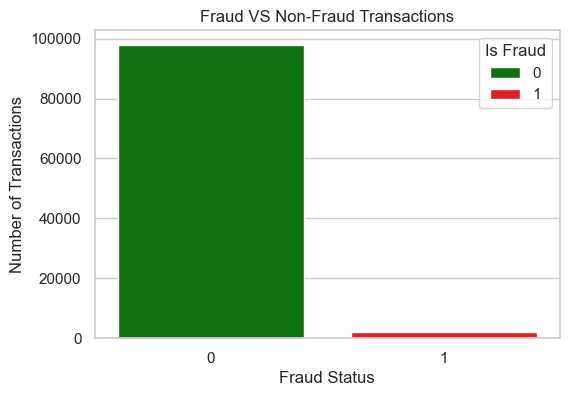

In [26]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(6,4))
sns.countplot(x='Is Fraud',hue='Is Fraud',data=df,palette=['green','red'])
plt.title('Fraud VS Non-Fraud Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Number of Transactions')
plt.show()

  <h5><i>Insight:</i></h5>
  <i>The dataset is highly imbalanced,with non-fraudluent transactions significantly outnumbering fraudulent transactions.
  Fraud cases account for a small percentage of the total transactions.</i>

<h4><i>Payment Channel Analysis</i></h4>

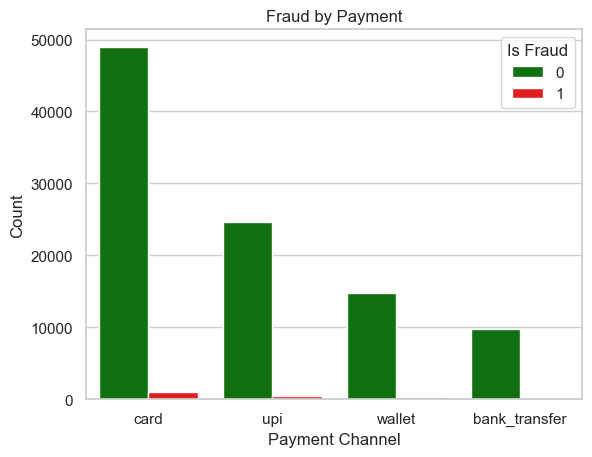

In [28]:
sns.countplot(x='Payment Channel',hue='Is Fraud',data=df,palette=['green','red'])
plt.title('Fraud by Payment')
plt.xlabel('Payment Channel')
plt.ylabel('Count')
plt.show()

 <h5><i>Insight:</i></h5>
<i> Card transactions have the highest transaction volume and also contributr to the  largest number of fraud cases.</i>

<h4><i>Device Type Analysis</i></h4>

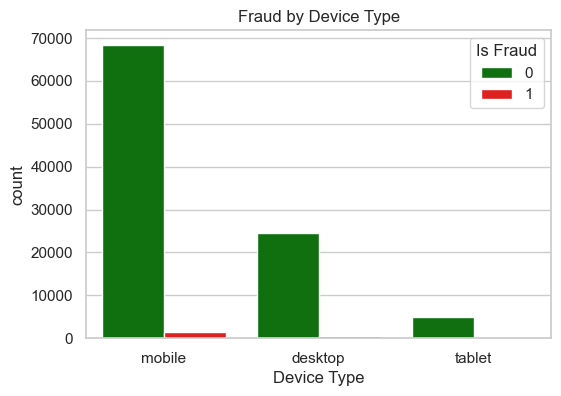

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='Device Type',hue='Is Fraud',data=df,palette=['green','red'])
plt.title('Fraud by Device Type')
plt.xlabel('Device Type')
plt.ylabel('count')
plt.show()


 <h5><i>Insight:</i></h5>
 <i>Most transactions are performed using mobile devices,and fraud cases are also concentrated on mobile transactions.</i>

<h4><i>Transaction Amount Distribution</i></h4>

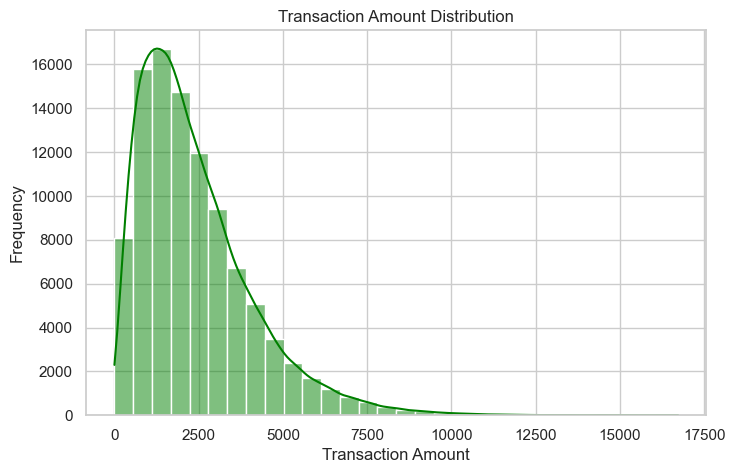

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Transaction Amount', bins=30, kde=True,palette=['green','red'])
plt.title('Transaction Amount Distribution') 
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()


 <h5><i>Insight:</i></h5>
 <i>Transaction amounts are right-skewed,with most transactions occuring at lower amounts and a small number of high-value transactions.</i>

<h4><i>Transaction Amount VS Fraud</i></h4>

C:\Users\rekharamadas\AppData\Local\Temp\ipykernel_392\2157693207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is Fraud',y='Transaction Amount',palette=['green','red'])


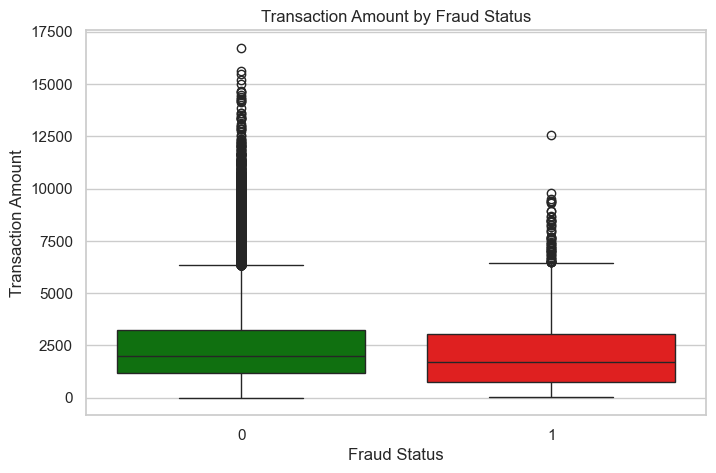

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Is Fraud',y='Transaction Amount','Is Fraud')
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')
plt.show()


 <h5><i>Insight:</i></h5>
 <i>Fraudulent transactions show greater variability and contain several high-vale outliers compared to non-fraudalent transactions.
 Transaction amount is an important predictor of fruad and should be considered during model development. </i>

<h4><i>International Transactions</i></h4>



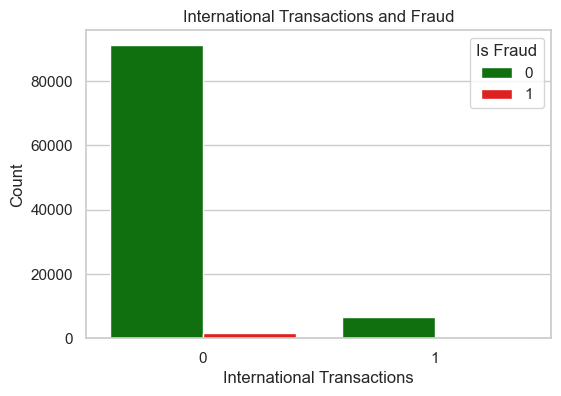

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='Is International',hue='Is Fraud',data=df,palette=['green','red'])
plt.title('International Transactions and Fraud')
plt.xlabel('International Transactions')
plt.ylabel('Count')
plt.show()

 <h5><i>Insight:</i></h5>
 <i>International transactions constitute a smaller portion of total transactions but exhibit a noticeable number of fraud cases.Cross-broder
 transactions may have a higher fruad risk and require additional authentication mechanisms.</i>

<h4><i>Fraud by Credit Score Band</i></h4>

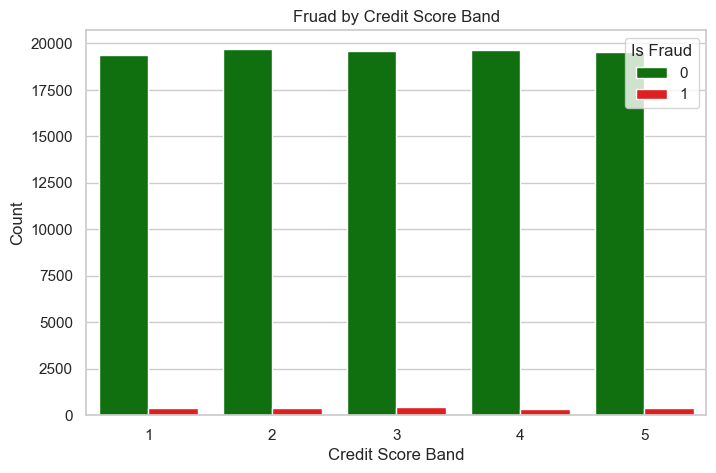

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(x='Credit Score Band',hue='Is Fraud',data=df,palette=['green','red'])
plt.title('Fruad by Credit Score Band')
plt.xlabel('Credit Score Band')
plt.ylabel('Count')
plt.show()

 <h5><i>Insight:</i></h5>
 <i>Fraud cases are observed across all credit score bands,with some bands showing slightly higher fraud occurences.</i>

<h4><i>KYC Levels</i></h4>

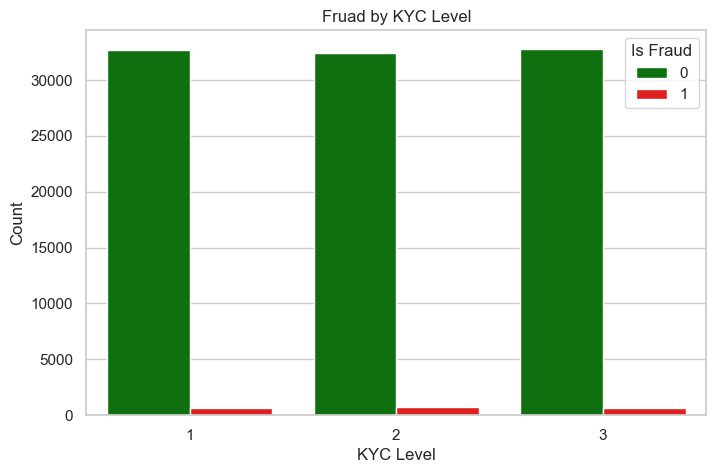

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='Kyc Level',hue='Is Fraud',data=df,palette=['green','red'])
plt.title('Fraud by KYC Level')
plt.xlabel('KYC Level')
plt.ylabel('Count')
plt.show()

 <h5><i>Insight:</i></h5>
 <i>Fraud occurs across all KYC levels,although lower KYC levels tend to exhibit relatively higher fraud cases.Stronger customer verification
 procedures may help reduce fraud exposure.</i>

<h4><i>Merchant Risk Score by fraud status </i></h4>

C:\Users\rekharamadas\AppData\Local\Temp\ipykernel_392\3812302711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is Fraud',y='Merchant Risk Score',data=df,palette=['green','red'])


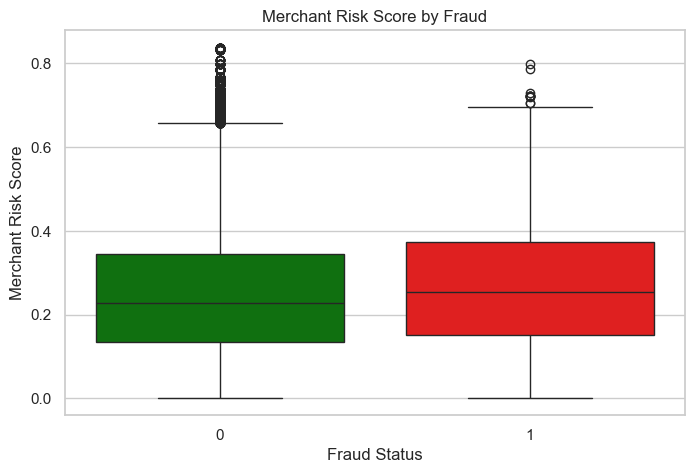

In [46]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Is Fraud',y='Merchant Risk Score',data=df,palette=['green','red'])
plt.title('Merchant Risk Score by Fraud')
plt.xlabel('Fraud Status')
plt.ylabel('Merchant Risk Score')
plt.show()

 <h5><i>Insight:</i></h5>
 <i>Fraudulent transactions generally have higher merchant risk scores than non-fraudulent tranactions.Merchant risk score is a strong indicator and may siginificantly contribute to fraud prediction.</i>
 

<h4><i>IP Risk Score</i></h4>

C:\Users\rekharamadas\AppData\Local\Temp\ipykernel_392\2016252276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is Fraud',y='Ip Risk Score',


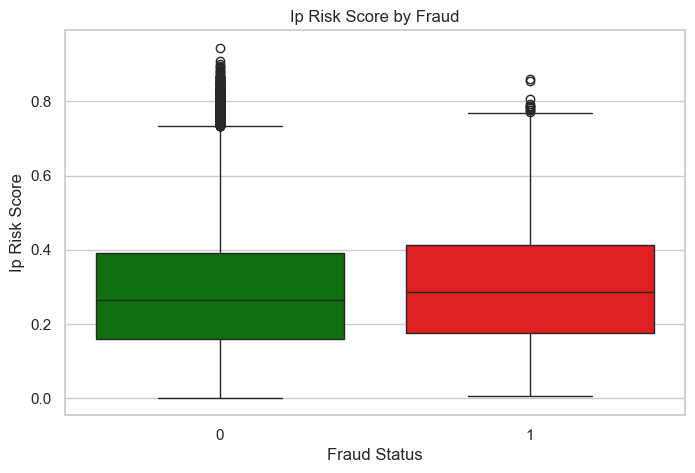

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Is Fraud',y='IP Risk Score',
data=df,palette=['green','red'])
plt.title('IP Risk Score by Fraud')
plt.xlabel('Fraud Status')
plt.ylabel('IP Risk Score')
plt.show()

 <h5><i>Insight:</i></h5>
 <i>Fraudulent transactions tend to have slightly higher IP risk scres compared to genuine transactions.IP reputation can serve as an important feature in identifying suspicious activities.</i>

<h4><i>Transaction Count in Last 24 Hours</i></h4>

C:\Users\rekharamadas\AppData\Local\Temp\ipykernel_392\2262469829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is Fraud',y='Txn Count 24H',


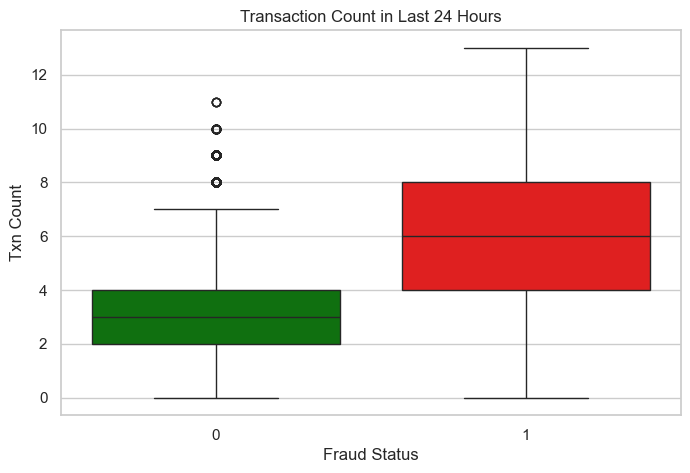

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Is Fraud',y='Txn Count 24H',
data=df,palette=['green','red'])
plt.title('Transaction Count in Last 24 Hours')
plt.xlabel('Fraud Status')
plt.ylabel('Txn Count')
plt.show()

 <h5><i>Insight:</i></h5>
 <i>Fraudulent transactions generally exhibit a higher number of transactions within the last 24 hours compared to non-fraudulent transactions.</i>

<h4><i>Correlation Heatmap</i></h4>

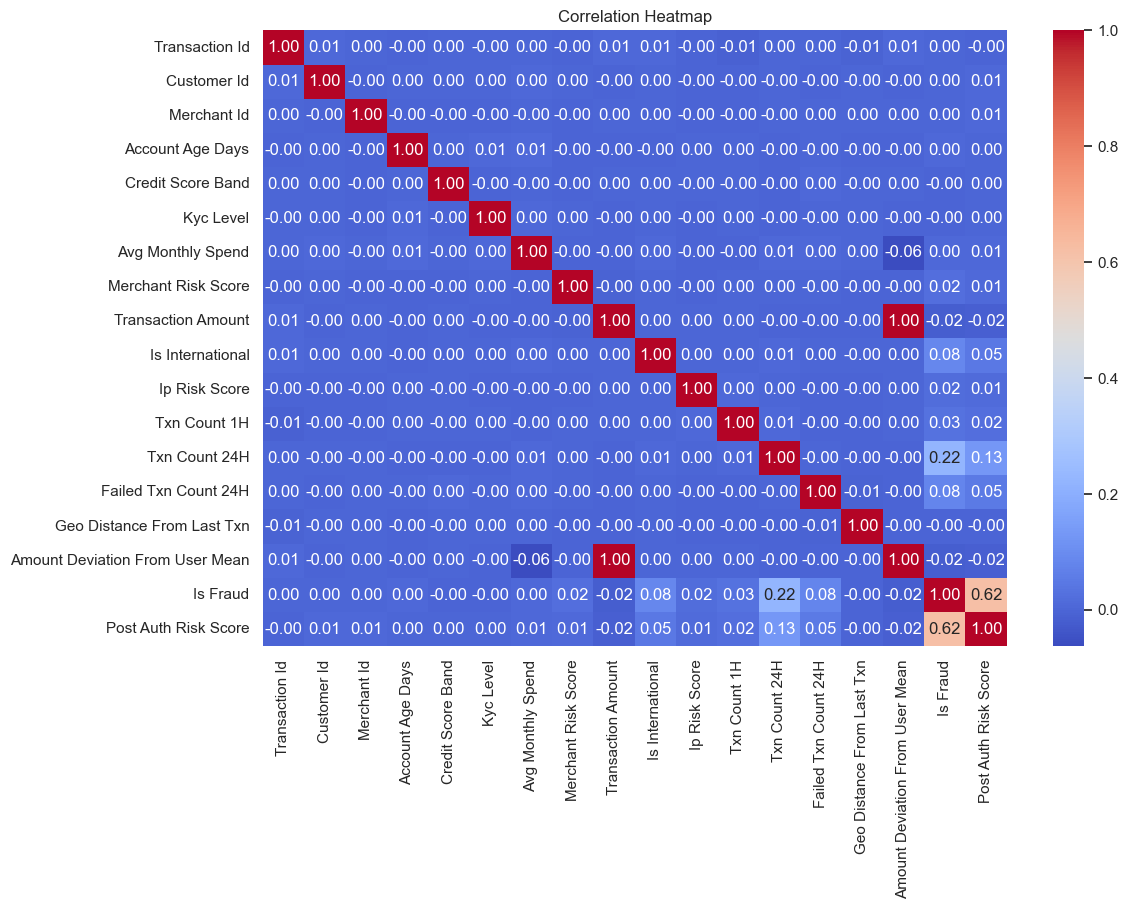

In [52]:
plt.figure(figsize=(12,8))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()            

 <h5><i>Insight:</i></h5>
 <i>Merchant Risk Score,IP Risk Score,Transaction Count,and Post Authentication Risk Score Show relatively stronger relationship with fraud occurrence.</i>

<h4><i>Fraud by hour of day</i></h4>

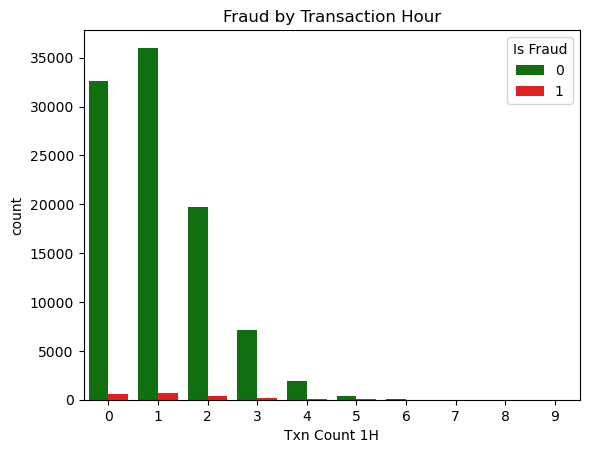

In [22]:
sns.countplot(x='Txn Count 1H',hue='Is Fraud',data=df,palette=['green','red'])
plt.title('Fraud by Transaction Hour')
plt.show()

 <h5><i>Insight:</i></h5>
 <i>Fraudulent transactions tend to occur more frequently during specific transaction hours.</i>

<h4><i>Fraud Percentage Pie Chart</i></h4>

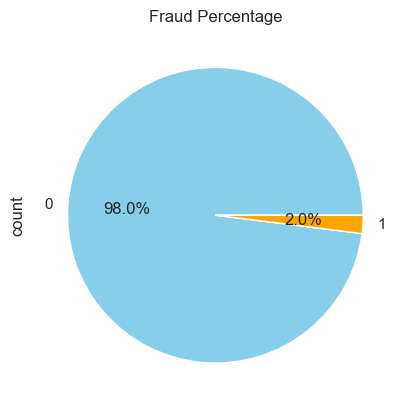

In [62]:
df['Is Fraud'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=['skyblue','orange'])
plt.title('Fraud Percentage')
plt.show()                                  

 <h5><i>Insight:</i></h5>
 <i>Approximately 98% of the transactions are legitimate, while only around 2% are fraudulent.</i>

<h4><i> Findings</i></h4>

<h4><i>Conclusion</i></h4>

<i>The analysis indicates that fraudulent transactions are influenced by behavioural transactional,and risk-related factors.
Features such as transaction frequency,transaction amount,merchant risk score,IP risk score,and transaction timing significantly contribute to fraud detection.Since fraud cases represent only small percentage of the datset.</i>

<h4><i>Recommendations</i></h4>